#inicio - Visualizar os dados




In [17]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/creditcard.csv')

print(df.head())


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [18]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

# value_counts

In [19]:
df['Class'].value_counts(normalize=True)
df['Amount_Log'] = np.log1p(df['Amount'])
df = df.drop(['Time', 'Amount'], axis=1)

# Divisão de treino e teste

In [20]:
# X = Tudo, MENOS a coluna Class (por isso o drop)
X = df.drop('Class', axis=1)

# y = APENAS a coluna Class
y = df['Class']

In [21]:
# Verifica quantos valores vazios existem na nossa variável alvo
print("Valores nulos em y:", y.isnull().sum())

# Vamos ver se também existem buracos nas variáveis de treino (X)
print("Valores nulos em X:\n", X.isnull().sum())

Valores nulos em y: 0
Valores nulos em X:
 V1            0
V2            0
V3            0
V4            0
V5            0
V6            0
V7            0
V8            0
V9            0
V10           0
V11           0
V12           0
V13           0
V14           0
V15           0
V16           0
V17           0
V18           0
V19           0
V20           0
V21           0
V22           0
V23           0
V24           0
V25           0
V26           0
V27           0
V28           0
Amount_Log    0
dtype: int64


In [22]:
# Remove linhas que tenham QUALQUER valor vazio
df = df.dropna()

# Atualiza o X e o y (porque o df original mudou, temos de atualizar as variáveis)
X = df.drop('Class', axis=1)
y = df['Class']

# Verifica se os nulos sumiram
print("Nulos restantes em y:", y.isnull().sum())

Nulos restantes em y: 0


In [23]:
from sklearn.model_selection import train_test_split

# Dividindo 80% para treinar e 20% para testar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Tamanho do Treino:", X_train.shape)
print("Tamanho do Teste:", X_test.shape)

Tamanho do Treino: (227845, 29)
Tamanho do Teste: (56962, 29)


In [24]:
!pip install imbalanced-learn

In [25]:
from imblearn.over_sampling import SMOTE

# 1. Criar o objeto SMOTE
# Usamos random_state para garantir que os exemplos criados sejam sempre os mesmos (reprodutibilidade)
smote = SMOTE(random_state=42)

# 2. Aplicar APENAS no Treino (Fit e Resample)
# "Aprenda com o treino e crie novos exemplos baseados nele"
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# 3. Vamos ver o milagre acontecer
print("Antes do SMOTE:", y_train.value_counts())
print("Depois do SMOTE:", y_train_resampled.value_counts())

Antes do SMOTE: Class
0    227451
1       394
Name: count, dtype: int64
Depois do SMOTE: Class
0    227451
1    227451
Name: count, dtype: int64


In [26]:
from sklearn.linear_model import LogisticRegression

# 1. Instanciar o modelo
model = LogisticRegression(random_state=42)

# 2. Treinar (Fit) com os dados balanceados (SMOTE)
model.fit(X_train_resampled, y_train_resampled)

# 3. Fazer previsões nos dados de Teste
y_pred = model.predict(X_test)

print("Previsões concluídas!")
print(y_pred[:20]) # Mostra as primeiras 20 previsões (0 ou 1)

Previsões concluídas!
[0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]


In [27]:
from sklearn.metrics import classification_report, confusion_matrix

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

Matriz de Confusão:
[[55342  1522]
 [    8    90]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962



# Random forest

In [28]:
from sklearn.ensemble import RandomForestClassifier

# 1. Criar o modelo (A Floresta)
# n_estimators=100 significa que teremos 100 árvores (padrão)
rf_model = RandomForestClassifier(random_state=42)

# 2. Treinar com os dados balanceados
rf_model.fit(X_train_resampled, y_train_resampled)

# 3. Prever no teste
y_pred_rf = rf_model.predict(X_test)

# 4. Avaliar
print("Matriz de Confusão (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))

print("\nRelatório de Classificação (Random Forest):")
print(classification_report(y_test, y_pred_rf))

Matriz de Confusão (Random Forest):
[[56854    10]
 [   18    80]]

Relatório de Classificação (Random Forest):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.89      0.82      0.85        98

    accuracy                           1.00     56962
   macro avg       0.94      0.91      0.93     56962
weighted avg       1.00      1.00      1.00     56962



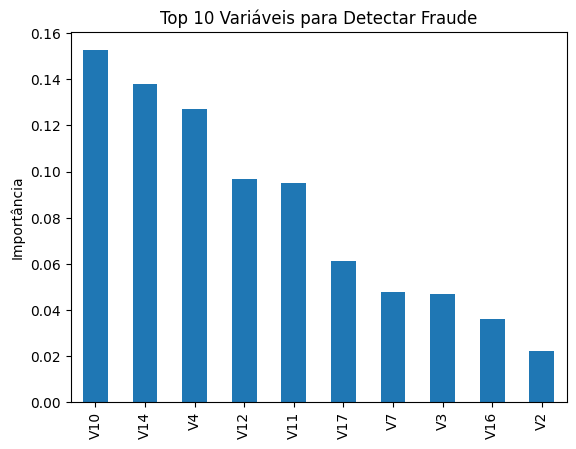

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

# Pegamos nas "importâncias" que o modelo calculou
importances = rf_model.feature_importances_

# Criamos uma tabela simples para ligar o nome da coluna à sua nota
# X.columns são os nomes (V1, V2, Amount_Log...)
feature_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

# Vamos plotar apenas as 10 mais importantes
feature_imp.head(10).plot(kind='bar', title='Top 10 Variáveis para Detectar Fraude')
plt.ylabel('Importância')
plt.show()